In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose

In [2]:
from jax import config
config.update("jax_enable_x64", True)
from refnx.reflect.extra._jax_compiler import compile_objective, make_scipy_objective, compile_global_objective, compile_model
import jax
from scipy.optimize._numdiff import approx_derivative
import jax.numpy as jnp
from jax import grad

In [3]:
from refnx.reflect import SLD, ReflectModel
from refnx.dataset import Data1D
from refnx.analysis import Objective, Parameter, GlobalObjective
from refnx.reflect._jax_reflect import jax_smeared_kernel_pointwise, jabeles
from refnx.reflect.reflect_model import reflectivity, abeles, gauss_legendre, _smeared_kernel_pointwise, _smeared_kernel_constant

In [4]:
data361 = Data1D("../refnx/analysis/tests/e361r.txt")
data365 = Data1D("../refnx/analysis/tests/e365r.txt")
si = SLD(2.07)
sio2 = SLD(3.47)
polymer = SLD(1.0)
d2o = SLD(6.36)
hdmix = SLD(3.47)
t1 = Parameter(15, bounds=(0, 20))
r1 = Parameter(3, bounds=(0, 10))

t2 = Parameter(150, bounds=(100, 300))
r2 = Parameter(3, bounds=(0, 10))
vf = Parameter(0.2, bounds=(0, 1))
pfilm = polymer(t2, r2, vfsolv=vf)

r3 = Parameter(3, bounds=(0, 10))


s361 = si | sio2(t1, r1) | pfilm | d2o(0, r3)
s365 = si | sio2(t1, r1) | pfilm | hdmix(0, r3)

model361 = ReflectModel(s361, dq_type='pointwise', dq=5.0, bkg=1e-5, quad_order=17)
model365 = ReflectModel(s365, dq_type='pointwise', dq=5.0, bkg=1e-5, quad_order=17)

r1.setp(vary=True, bounds=(1, 10))
r2.setp(vary=True, bounds=(1, 10))
r3.setp(vary=True, bounds=(1, 10))

t1.setp(vary=True, bounds=(1, 30))
t2.setp(vary=True, bounds=(100, 300))
vf.setp(vary=True, bounds=(0, 1))
polymer.real.setp(vary=True, bounds=(0.5, 2))


model361.bkg.setp(vary=True, bounds=(1e-5, 5e-5))
model361.scale.setp(vary=True, bounds=(0.9, 1.1))

model365.bkg.setp(vary=True, bounds=(1e-5, 5e-5))
model365.scale.setp(vary=True, bounds=(0.9, 1.1))

# slabs = s.slabs()

data361.x_err = 0.05 * data361.x
data365.x_err = 0.05 * data365.x

objective361 = Objective(model361, data361)
objective365 = Objective(model365, data365)

global_objective = GlobalObjective([objective361, objective365])

In [5]:
co361 = compile_objective(objective361)
co365 = compile_objective(objective365)
gco = compile_global_objective(global_objective)

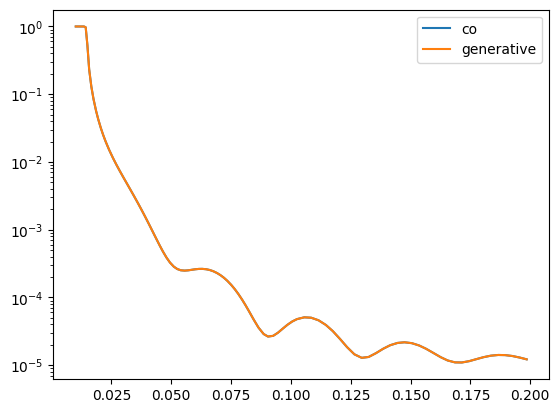

In [6]:
cm = compile_model(model361)
rng = np.random.default_rng()

# reflectivity at the initial parameters:
R = cm.model(cm.x0, data361.x, data361.x_err)

# Jacobian dR/dp — shape (n_q_points, n_free):
J = cm.jacfwd(cm.x0, data361.x, data361.x_err)

plt.plot(data361.x, R, label='co')
plt.plot(data361.x, objective361.generative(), label='generative')
plt.legend();
plt.yscale("log")

In [7]:
g_nll, g_grad_nll = make_scipy_objective(gco)
nll361, grad_nll361 = make_scipy_objective(co361)
nll365, grad_nll365 = make_scipy_objective(co365)

In [8]:
print(nll361(co361.x0), objective361.nll())
assert_allclose(nll361(co361.x0), objective361.nll())

print(nll365(co365.x0), objective365.nll())
assert_allclose(nll365(co365.x0), objective365.nll())

print(g_nll(gco.x0), global_objective.nll())
assert_allclose(g_nll(gco.x0), global_objective.nll())

8748.020510037066 8748.020510037064
19427.734509113696 19427.734509113703
28175.75501915076 28175.75501915077


In [9]:
%timeit gco.value_and_grad(gco.x0)

1.27 ms ± 6.08 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [10]:
%timeit g_nll(gco.x0)

1.32 ms ± 27.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [11]:
%timeit global_objective.nll()

372 μs ± 5.72 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [12]:
%timeit g_grad_nll(gco.x0)

1.3 ms ± 3.01 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [13]:
x0 = np.array(global_objective.varying_parameters())
f0 = global_objective.nll()
%timeit approx_derivative(global_objective.nll, x0, method='2-point', f0=f0)

4.75 ms ± 20.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
np.testing.assert_allclose(
    g_grad_nll(gco.x0),
    approx_derivative(global_objective.nll, x0, method='3-point')
)

Timings for val_and_grad:

jax individually: 2.66

jax val_and_grad: 1.27

'normal': 5.06